<a href="https://colab.research.google.com/github/AnjaliAleti/Aleti_INFO5731_Fall2024/blob/main/Aleti_Anjali_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

display(df.head())

Saving cleaned data set.csv to cleaned data set.csv


,paperId,title,abstract,year,venue,url,authors,clean_text
0,00000c33779acab142af6c7a6dae8b36fac0805d,Insights into Household Electric Vehicle Charg...,In the era of burgeoning electric vehicle (EV)...,2024.0,Energies,https://www.semanticscholar.org/paper/00000c33...,"Ahmad Almaghrebi, Kevin James, Fares al Juhesh...",era burgeoning electric vehicle ev popularity ...
1,0000238f07f151172cf2602588ba762b55c8464b,Personalized Prediction of Response to Smartph...,Background Meditation apps have surged in popu...,2021.0,Journal of Medical Internet Research,https://www.semanticscholar.org/paper/0000238f...,"Christian A. Webb, M. Hirshberg, R. Davidson, ...",background meditation apps surged popularity r...
2,00002d31a8c758062a51d9a259313d81a5eaf399,A Machine Learning Method to Quantify the Role...,NaN,2020.0,International Conference on Information System...,https://www.semanticscholar.org/paper/00002d31...,"L. Szczyrba, Yang Zhang, D. Pamukçu, D. Eroglu",NaN
3,0000315635be19f6278dbc72597b3065fac405f0,Abstractive text summarization of low-resource...,Background Humans must be able to cope with th...,2023.0,PeerJ Computer Science,https://www.semanticscholar.org/paper/00003156...,"Nida Shafiq, Isma Hamid, Muhammad Asif, Qamar ...",background human must able cope huge amount in...
4,00005d68c6c7eb4d3c27da8242a30b9a498f991e,Detection of DDoS Attacks on Clouds Computing ...,The growing number of cloud-based services has...,2023.0,International Conference on Communication and ...,https://www.semanticscholar.org/paper/00005d68...,"Iehab Alrassan, Asma Alqahtani",growing number cloud based service led rising ...


In [ ]:

possible_text_columns = ['review', 'reviews', 'text', 'abstract', 'tweet', 'content', 'comments']

text_col = None
for col in df.columns:
    if col.lower() in possible_text_columns:
        text_col = col
        break

if text_col is None:
    print("\nColumns in dataset:", df.columns.tolist())
    text_col = input("Enter the name of the text column to use: ")

print("\nUsing text column:", text_col)


df = df[[text_col]].dropna().reset_index(drop=True)
df = df.iloc[:100].copy()

print("\nTotal reviews used:", len(df))


Using text column: abstract

Total reviews used: 100


In [ ]:
import re

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return text.split()

df["clean_text"] = df[text_col].apply(preprocess_text)
df["tokens"] = df["clean_text"].apply(tokenize)

print("\nSample cleaned review:")
print(df.loc[0, "clean_text"])


Sample cleaned review:
in the era of burgeoning electric vehicle ev popularity understanding the patterns of ev users behavior is imperative this paper examines the trends in household charging sessions timing duration and energy consumption by analyzing real world residential charging data by leveraging the information collected from each session a novel framework is introduced for the efficient real time prediction of important charging characteristics utilizing historical data and user specific features machine learning models are trained to predict the connection duration charging duration charging demand and time until the next session these models enhance the understanding of ev users behavior and provide practical tools for optimizing the ev charging infrastructure and effectively managing the charging demand as the transportation sector becomes increasingly electrified this work aims to empower stakeholders with insights and reliable models enabling them to anticipate the loca

In [ ]:

unigram_counts = {}
bigram_counts = {}
trigram_counts = {}

for tokens in df["tokens"]:
    # Count unigrams
    for word in tokens:
        if word in unigram_counts:
            unigram_counts[word] += 1
        else:
            unigram_counts[word] = 1

    # Count bigrams
    for i in range(len(tokens) - 1):
        bg = (tokens[i], tokens[i+1])
        if bg in bigram_counts:
            bigram_counts[bg] += 1
        else:
            bigram_counts[bg] = 1

    # Count trigrams
    for i in range(len(tokens) - 2):
        tg = (tokens[i], tokens[i+1], tokens[i+2])
        if tg in trigram_counts:
            trigram_counts[tg] += 1
        else:
            trigram_counts[tg] = 1

In [ ]:


bigram_table = pd.DataFrame(
    [(bg[0], bg[1], count) for bg, count in bigram_counts.items()],
    columns=["Word1", "Word2", "Bigram_Count"]
).sort_values(by="Bigram_Count", ascending=False).reset_index(drop=True)

trigram_table = pd.DataFrame(
    [(tg[0], tg[1], tg[2], count) for tg, count in trigram_counts.items()],
    columns=["Word1", "Word2", "Word3", "Trigram_Count"]
).sort_values(by="Trigram_Count", ascending=False).reset_index(drop=True)

print("\nTop 20 Bigrams:")
print(bigram_table.head(20))

print("\nTop 20 Trigrams:")
print(trigram_table.head(20))


Top 20 Bigrams:
         Word1         Word2  Bigram_Count
0           of           the           137
1      machine      learning           113
2           in           the            91
3          and           the            47
4        based            on            46
5           on           the            41
6           in          this            39
7         with           the            36
8         this         study            31
9         this         paper            31
10        deep      learning            29
11        such            as            28
12          to           the            28
13         for           the            27
14        that           the            26
15         the      proposed            24
16          to       predict            24
17  artificial  intelligence            23
18        from           the            21
19         the         study            21

Top 20 Trigrams:
      Word1        Word2       Word3  Trigram_Count
0        i

In [ ]:


bigram_probability_rows = []

for bg, bg_count in bigram_counts.items():
    w1, w2 = bg
    w1_count = unigram_counts[w1]
    prob = bg_count / w1_count
    bigram_probability_rows.append([w1, w2, bg_count, w1_count, prob])

bigram_probability_table = pd.DataFrame(
    bigram_probability_rows,
    columns=["Word1", "Word2", "Bigram_Count", "Count_Word1", "Probability"]
).sort_values(by="Probability", ascending=False).reset_index(drop=True)

print("\nTop 20 Bigram Probabilities:")
print(bigram_probability_table.head(20))



Top 20 Bigram Probabilities:
           Word1       Word2  Bigram_Count  Count_Word1  Probability
0        learned        data             1            1          1.0
1      singleton      vertex             1            1          1.0
2    nulliparous        term             1            1          1.0
3     physicians        with             1            1          1.0
4      delivered          by             1            1          1.0
5       tertiary        care             1            1          1.0
6       endanger         the             1            1          1.0
7   misdiagnosis        even             1            1          1.0
8         tables       which             1            1          1.0
9        datsets          we             1            1          1.0
10     extremely     limited             1            1          1.0
11      unbiased   molecular             1            1          1.0
12   microsecond        long             1            1          1.0
13  

In [ ]:


# Try spaCy first
use_spacy = True

try:
    import spacy
    try:
        nlp = spacy.load("en_core_web_sm")
    except:
        import sys
        !{sys.executable} -m pip install spacy
        !{sys.executable} -m spacy download en_core_web_sm
        nlp = spacy.load("en_core_web_sm")
except:
    use_spacy = False

noun_phrases_per_review = []

if use_spacy:
    for text in df["clean_text"]:
        doc = nlp(text)
        noun_phrases = []
        for chunk in doc.noun_chunks:
            np_text = chunk.text.strip().lower()
            np_text = re.sub(r"\s+", " ", np_text)
            if np_text != "":
                noun_phrases.append(np_text)
        noun_phrases_per_review.append(noun_phrases)
else:
    print("spaCy not available. Install spaCy manually and run again.")


df["noun_phrases"] = noun_phrases_per_review

print("\nSample noun phrases from first review:")
print(df.loc[0, "noun_phrases"])


Sample noun phrases from first review:
['the era', 'burgeoning electric vehicle', 'popularity', 'the patterns', 'ev users behavior', 'this paper', 'the trends', 'sessions', 'duration and energy consumption', 'data', 'the information', 'each session', 'a novel framework', 'the efficient real time prediction', 'important charging characteristics', 'historical data', 'user specific features machine learning models', 'the connection duration', 'duration charging demand', 'time', 'the next session', 'these models', 'the understanding', 'users behavior', 'practical tools', 'the ev charging infrastructure', 'the charging demand', 'the transportation sector', 'this work', 'stakeholders', 'insights', 'reliable models', 'them', 'the localized demand', 'the sustainable integration', 'electric vehicles', 'the grid']


In [ ]:

np_global_counts = {}

for np_list in df["noun_phrases"]:
    for np_item in np_list:
        if np_item in np_global_counts:
            np_global_counts[np_item] += 1
        else:
            np_global_counts[np_item] = 1

# Sort noun phrases by frequency
np_freq_table = pd.DataFrame(
    [(np_item, count) for np_item, count in np_global_counts.items()],
    columns=["Noun_Phrase", "Frequency"]
).sort_values(by="Frequency", ascending=False).reset_index(drop=True)

print("\nTop 20 Noun Phrases in Whole Dataset:")
print(np_freq_table.head(20))



Top 20 Noun Phrases in Whole Dataset:
         Noun_Phrase  Frequency
0                 we        121
1               that         74
2              which         58
3                 it         57
4         this paper         30
5         this study         30
6                you         21
7               this         20
8   machine learning         20
9               data         19
10              they         16
11         the study         16
12              them         15
13               who         13
14          the need         12
15       the results         12
16         this work         11
17     the algorithm         11
18           the use         10
19     the potential         10


In [ ]:


all_noun_phrases = list(np_global_counts.keys())

# Create review names
review_names = [f"Review_{i+1}" for i in range(len(df))]

relative_prob_table = pd.DataFrame(0.0, index=review_names, columns=all_noun_phrases)

for review_index, np_list in enumerate(df["noun_phrases"]):
    local_counts = {}

    # Count noun phrase frequency inside each review
    for np_item in np_list:
        if np_item in local_counts:
            local_counts[np_item] += 1
        else:
            local_counts[np_item] = 1

    # Compute relative probabilities
    for np_item, local_freq in local_counts.items():
        max_freq = np_global_counts[np_item]
        relative_prob = local_freq / max_freq
        relative_prob_table.loc[f"Review_{review_index+1}", np_item] = relative_prob

print("\nRelative Probability Table:")
print(relative_prob_table)


Relative Probability Table:
            the era  burgeoning electric vehicle  popularity  the patterns  \
Review_1        0.5                          1.0    0.333333           1.0   
Review_2        0.0                          0.0    0.333333           0.0   
Review_3        0.0                          0.0    0.000000           0.0   
Review_4        0.0                          0.0    0.000000           0.0   
Review_5        0.0                          0.0    0.000000           0.0   
...             ...                          ...         ...           ...   
Review_96       0.0                          0.0    0.000000           0.0   
Review_97       0.0                          0.0    0.000000           0.0   
Review_98       0.0                          0.0    0.000000           0.0   
Review_99       0.0                          0.0    0.000000           0.0   
Review_100      0.0                          0.0    0.000000           0.0   

            ev users behavior  thi

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [ ]:
import pandas as pd
import re
import math

possible_cols = ['review', 'text', 'abstract', 'tweet', 'content']

text_col = None
for col in df.columns:
    if col.lower() in possible_cols:
        text_col = col
        break

if text_col is None:
    print(df.columns)
    text_col = input("Enter text column name: ")

print("Using column:", text_col)

df = df[[text_col]].dropna().reset_index(drop=True)
df = df.iloc[:100]

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return text.split()

df["clean"] = df[text_col].apply(preprocess)
df["tokens"] = df["clean"].apply(tokenize)

vocab = set()

for tokens in df["tokens"]:
    for word in tokens:
        vocab.add(word)

vocab = sorted(list(vocab))
print("Vocabulary size:", len(vocab))

tf = []

for tokens in df["tokens"]:
    tf_doc = {}
    total_words = len(tokens)

    for word in vocab:
        count = tokens.count(word)
        tf_doc[word] = count / total_words if total_words > 0 else 0

    tf.append(tf_doc)

df_counts = {}

for word in vocab:
    count = 0
    for tokens in df["tokens"]:
        if word in tokens:
            count += 1
    df_counts[word] = count

N = len(df)

idf = {}

for word in vocab:
    idf[word] = math.log(N / (1 + df_counts[word]))

tfidf = []

for tf_doc in tf:
    tfidf_doc = {}
    for word in vocab:
        tfidf_doc[word] = tf_doc[word] * idf[word]
    tfidf.append(tfidf_doc)

tfidf_matrix = pd.DataFrame(tfidf)

print("\nTF-IDF Matrix:")
print(tfidf_matrix.head())

query = "outstanding movie with haunting performance and character development"

query_clean = preprocess(query)
query_tokens = tokenize(query_clean)

query_tf = {}
total_q_words = len(query_tokens)

for word in vocab:
    count = query_tokens.count(word)
    query_tf[word] = count / total_q_words if total_q_words > 0 else 0

query_tfidf = {}

for word in vocab:
    query_tfidf[word] = query_tf[word] * idf[word]

def cosine_similarity(vec1, vec2):
    dot = 0
    mag1 = 0
    mag2 = 0

    for word in vocab:
        dot += vec1[word] * vec2[word]
        mag1 += vec1[word] ** 2
        mag2 += vec2[word] ** 2

    mag1 = math.sqrt(mag1)
    mag2 = math.sqrt(mag2)

    if mag1 == 0 or mag2 == 0:
        return 0

    return dot / (mag1 * mag2)

scores = []

for i, doc_vec in enumerate(tfidf):
    sim = cosine_similarity(doc_vec, query_tfidf)
    scores.append((i + 1, sim))

scores = sorted(scores, key=lambda x: x[1], reverse=True)

ranking_df = pd.DataFrame(scores, columns=["Document", "Cosine_Similarity"])

print("\nTop Ranked Documents:")
print(ranking_df.head(10))

tfidf_matrix.to_csv("tfidf_matrix.csv", index=False)
ranking_df.to_csv("document_ranking.csv", index=False)


Using column: abstract
Vocabulary size: 4874

TF-IDF Matrix:
          a   ab  abaixo  abaqus  abbreviations  abilities  ability  abla  \
0  0.000134  0.0     0.0     0.0            0.0        0.0      0.0   0.0   
1  0.000754  0.0     0.0     0.0            0.0        0.0      0.0   0.0   
2  0.000455  0.0     0.0     0.0            0.0        0.0      0.0   0.0   
3  0.000345  0.0     0.0     0.0            0.0        0.0      0.0   0.0   
4  0.000772  0.0     0.0     0.0            0.0        0.0      0.0   0.0   

   ablation      able  ...  you  young  your  yzf    z  zero  zone  zones  \
0       0.0  0.000000  ...  0.0    0.0   0.0  0.0  0.0   0.0   0.0    0.0   
1       0.0  0.000000  ...  0.0    0.0   0.0  0.0  0.0   0.0   0.0    0.0   
2       0.0  0.012673  ...  0.0    0.0   0.0  0.0  0.0   0.0   0.0    0.0   
3       0.0  0.000000  ...  0.0    0.0   0.0  0.0  0.0   0.0   0.0    0.0   
4       0.0  0.000000  ...  0.0    0.0   0.0  0.0  0.0   0.0   0.0    0.0   

    zs  zte  

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


In [ ]:


import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

try:
    from gensim.models import Word2Vec
except:
    !pip install gensim
    from gensim.models import Word2Vec

try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
except:
    !pip install scikit-learn
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 25.3 MB/s eta 0:00:00


In [ ]:

possible_cols = ['review', 'reviews', 'text', 'abstract', 'tweet', 'content']
text_col = None

for col in df.columns:
    if col.lower() in possible_cols:
        text_col = col
        break

if text_col is None:
    print("Columns are:", df.columns.tolist())
    text_col = input("Enter the text column name: ")

print("\nUsing column:", text_col)


Using column: abstract


In [ ]:


def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return text.split()

df = df[[text_col]].dropna().reset_index(drop=True)
df["clean_text"] = df[text_col].apply(preprocess)
df["tokens"] = df["clean_text"].apply(tokenize)

print("\nSample tokens:")
print(df["tokens"].head())



Sample tokens:
0    [in, the, era, of, burgeoning, electric, vehic...
1    [background, meditation, apps, have, surged, i...
2    [background, humans, must, be, able, to, cope,...
3    [the, growing, number, of, cloud, based, servi...
4    [diffusion, generative, models, a, class, of, ...
Name: tokens, dtype: object


In [ ]:


sentences = df["tokens"].tolist()

print("\nNumber of documents:", len(sentences))
print("Sample sentence:", sentences[0][:20])


Number of documents: 100
Sample sentence: ['in', 'the', 'era', 'of', 'burgeoning', 'electric', 'vehicle', 'ev', 'popularity', 'understanding', 'the', 'patterns', 'of', 'ev', 'users', 'behavior', 'is', 'imperative', 'this', 'paper']


In [ ]:


model = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=20
)

print("\nWord2Vec model trained successfully.")
print("Vocabulary size:", len(model.wv.index_to_key))




Word2Vec model trained successfully.
Vocabulary size: 4874


In [ ]:


sample_word = "data"
if sample_word in model.wv:
    print(f"\nMost similar words to '{sample_word}':")
    print(model.wv.most_similar(sample_word, topn=10))
else:
    print(f"\n'{sample_word}' not found in vocabulary.")



Most similar words to 'data':
[('big', 0.8653929829597473), ('driven', 0.8635788559913635), ('resource', 0.8593859672546387), ('collection', 0.840796947479248), ('amount', 0.8252803087234497), ('historical', 0.8190256357192993), ('analytics', 0.8187000155448914), ('twins', 0.8147263526916504), ('strategies', 0.814624011516571), ('wearable', 0.8141833543777466)]


In [ ]:

words_to_plot = model.wv.index_to_key[:20]

print("\nWords selected for visualization:")
print(words_to_plot)



Words selected for visualization:
['the', 'and', 'of', 'to', 'a', 'in', 'for', 'is', 'this', 'learning', 'with', 'data', 'manual', 'that', 'on', 'machine', 'as', 'we', 'are', 'de']


In [ ]:


word_vectors = np.array([model.wv[word] for word in words_to_plot])


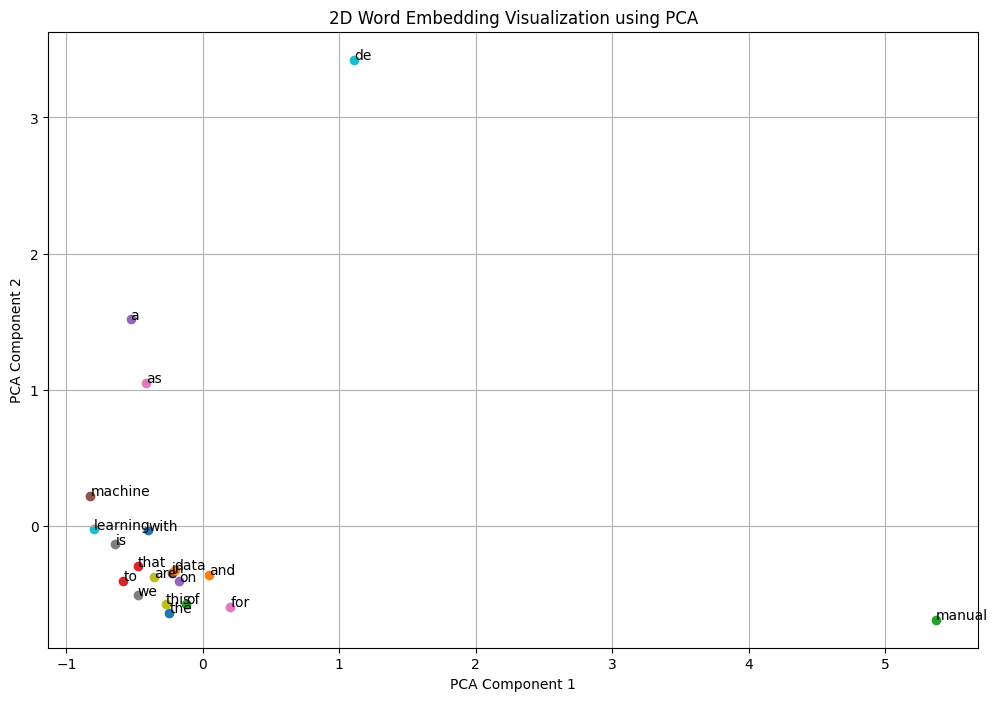

In [ ]:


pca = PCA(n_components=2)
word_vectors_2d_pca = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
for i, word in enumerate(words_to_plot):
    x = word_vectors_2d_pca[i, 0]
    y = word_vectors_2d_pca[i, 1]
    plt.scatter(x, y)
    plt.annotate(word, (x, y))

plt.title("2D Word Embedding Visualization using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


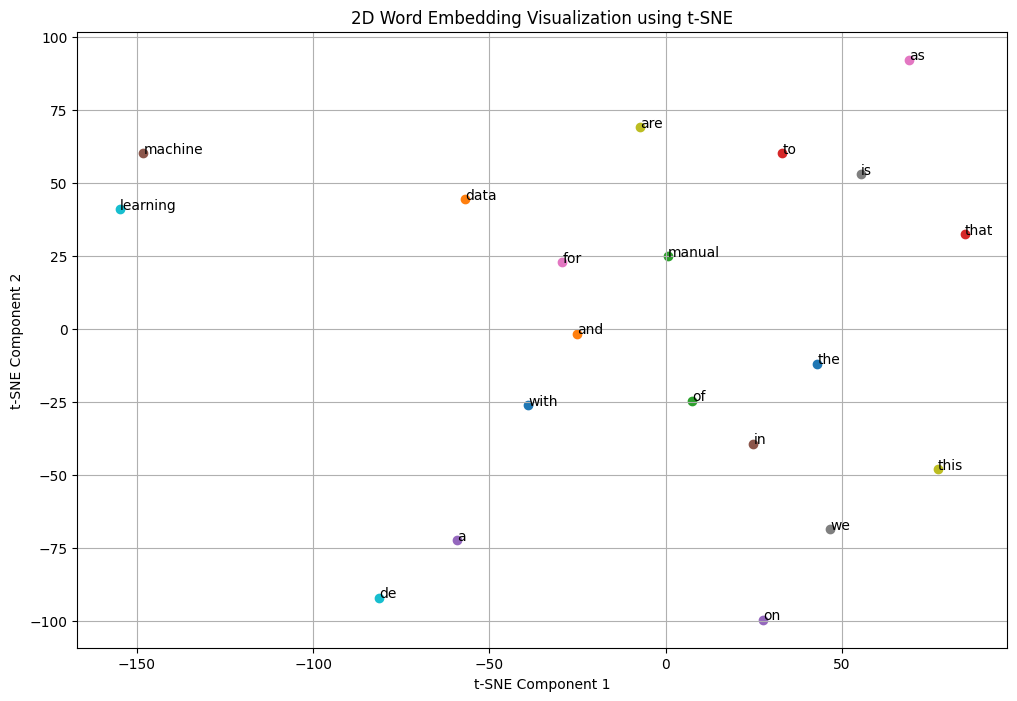

In [ ]:


tsne = TSNE(n_components=2, random_state=42, perplexity=5)
word_vectors_2d_tsne = tsne.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
for i, word in enumerate(words_to_plot):
    x = word_vectors_2d_tsne[i, 0]
    y = word_vectors_2d_tsne[i, 1]
    plt.scatter(x, y)
    plt.annotate(word, (x, y))

plt.title("2D Word Embedding Visualization using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()


In [ ]:


word_pairs = [
    ("data", "information"),
    ("model", "algorithm"),
    ("learning", "training"),
    ("health", "medical"),
    ("study", "research")
]

print("\nCosine Similarity Between Word Pairs:")
for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        print(f"{w1} - {w2}: {sim:.4f}")
    else:
        print(f"{w1} - {w2}: One or both words not found in vocabulary.")


Cosine Similarity Between Word Pairs:
data - information: 0.7890
model - algorithm: 0.7932
learning - training: 0.6101
health - medical: 0.8873
study - research: 0.7384


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


In [ ]:
# The GitHub link of your final csv file


# Link:https://github.com/AnjaliAleti/Aleti_INFO5731_Fall2024/blob/main/Devara%20Reviews.csv



The NLP task selected for this dataset is sentiment analysis, which focuses on classifying each movie review based on the emotional tone expressed in the text. Since the dataset consists of Devara movie reviews, sentiment analysis is suitable for understanding audience opinions and reactions. A three-class labeling schema was used, consisting of positive, negative, and neutral labels. Reviews expressing appreciation, strong performances, or overall satisfaction were labeled as positive, while reviews showing criticism, disappointment, or negative feedback were labeled as negative. Reviews that were descriptive, balanced, or did not convey a strong opinion were labeled as neutral. The labeling process involved analyzing the tone, keywords, and overall context of each review, and in some cases, AI assistance was used to speed up the annotation process while ensuring consistency. The final dataset includes three columns—document_id, clean_text, and sentiment—and will be used in subsequent tasks for building and evaluating sentiment classification models.

# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

In [ ]:
# # Type your

# I found this assignment to be very practical and helpful in understanding core NLP concepts such as N-grams, TF-IDF, and word embeddings. One of the challenging aspects was implementing everything from scratch, especially TF-IDF and cosine similarity, as it required careful handling of formulas and data structures without relying on built-in libraries. Additionally, labeling the dataset manually for sentiment analysis was time-consuming and required consistent judgment. However, I really enjoyed working on the word embedding part, particularly visualizing the embeddings using PCA and t-SNE, as it gave a clear intuition of how similar words cluster together. Overall, the assignment was engaging and improved my understanding of real-world NLP workflows. The time provided to complete the assignment was reasonable, although slightly more time for the labeling task would have been beneficial.